In [7]:
import sys

assert sys.version_info >= (3,10)

In [8]:
import torch
from packaging.version import Version

assert Version(torch.__version__) >= Version("2.6.0")

In [9]:
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

In [10]:
from pathlib import Path

IMAGES_PATH =Path() / "images" / "08_Burgers_Equation_Spatio_Temporal_Domain"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, fig_extension="png", tight_layout=True, resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

In [11]:
import deepxde as dde
from deepxde import utils
import numpy as np

dde.config.set_random_seed(42)
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)

In [12]:
dde.config.set_default_float("float64")
print(f"Backend: {dde.backend.backend_name}")

Set the default float type to float64
Backend: pytorch


Generating Spatio-Temporal Data using high fidelity integration

In [13]:
from scipy.integrate import solve_ivp
import numpy as np

nu = 0.01 / np.pi
N = 256
L  = 2.0

x_space = np.linspace(-1, 1, N, endpoint=False)
dx = x_space[1] - x_space[0]

t_span = (0.0, 1.0)
t_steps = np.linspace(0, 1, 100)
u0 = -np.sin(np.pi * x_space)
k = 2 * np.pi * np.fft.fftfreq(N, d=dx)
k2 = k ** 2
def burgers_rhs(t, u):
    u_hat = np.fft.fft(u)
    du_dx = np.real(np.fft.ifft(1j * k * u_hat))
    d2u_dx2 = np.real(np.fft.ifft(-k2 * u_hat))
    return -u * du_dx + nu * d2u_dx2

print("Integrating Burgers' equation...")
sol = solve_ivp(burgers_rhs, t_span=t_span, y0=u0,t_eval=t_steps,method="RK45", rtol=1e-8,atol=1e-10)

x_grid = x_space.reshape(-1, 1)
t_grid = sol.t.reshape(-1, 1)
usol = sol.y.T

filename = "Burgers_exact.npz"
np.savez(filename, x=x_grid, t=t_grid, usol=usol)
print(f"Dataset successfully created and saved as '{filename}'.\n")


Integrating Burgers' equation...
Dataset successfully created and saved as 'Burgers_exact.npz'.



Preparing the generated data for training

In [14]:
X_mesh, T_mesh = np.meshgrid(x_space, sol.t)
X_data_points = np.hstack((X_mesh.flatten()[:, None], T_mesh.flatten()[:, None]))
y_data_values = usol.flatten()[:, None]

Defining geometric Boundaries and Spatio-Temporal Domain

In [15]:
geom = dde.geometry.Interval(-1, 1)
timedomain = dde.geometry.TimeDomain(0, 1)
geomtime = dde.geometry.GeometryXTime(geom, timedomain)

Define Burgers PDE Physics Residual

In [16]:
def burgers_pde(x, y):
    dy_x = dde.grad.jacobian(y, x, i=0, j=0)
    dy_t = dde.grad.jacobian(y, x, i=0, j=1)
    dy_xx = dde.grad.hessian(y, x, i=0, j=0)
    return dy_t + y * dy_x - nu * dy_xx

Define Boundary Conditions and Initial Conditions

In [18]:
def boundary_on(x, on_boundary):
    return on_boundary
# Since we are working on bc same on both sides we dont need np.isclose here

bc = dde.icbc.DirichletBC(geomtime, lambda x: 0, boundary_on)
ic = dde.icbc.IC(geomtime, lambda x: -np.sin(np.pi * x[:, 0:1]), lambda x, on_initial: on_initial)

data_bcond = dde.icbc.PointSetBC(X_data_points, y_data_values)

Combining all of the for training

In [19]:
data = dde.data.TimePDE(
    geomtime, burgers_pde,[bc, ic, data_bcond],
    num_domain=2500, num_boundary=100, num_initial=150
)

Build a NN and a model

In [21]:
net  = dde.nn.FNN([2, 20, 20, 20, 1], "tanh", "Glorot normal")

model = dde.Model(data, net)

In [22]:
class SoftmaxAdaptiveWeights(dde.callbacks.Callback):
    def __init__(self, model, every_n_epochs=100, alpha_0=1.0, gamma=0.999):
        super().__init__()
        self.model = model
        self.every_n_epochs = every_n_epochs
        self.alpha = alpha_0
        self.gamma = gamma
        self.epoch = 0

    def on_epoch_end(self):
        self.epoch += 1
        if self.epoch % self.every_n_epochs != 0:
            return
        if len(self.model.losshistory.loss_train) == 0:
            return
        current_losses = self.model.losshistory.loss_train[-1]
        exp_terms = np.exp(self.alpha * np.array(current_losses))
        new_weights = exp_terms / np.sum(exp_terms)
        self.alpha *= self.gamma
        self.model.loss_weights = new_weights.tolist()
        print(f"Epoch {self.epoch}: Adaptive weights updated to {new_weights.tolist()}, alpha decayed to {self.alpha:.4f}")

adaptive_callback = SoftmaxAdaptiveWeights(model, every_n_epochs=20)

Training the model 

In [23]:
print("\n stage 1: Adam Optimizer")
model.compile(
    "adam", lr=0.001,
    loss_weights=[1.0] * 4,
    decay=("inverse time", 1000, 0.1)
)
losshistory, train_state = model.train(iterations=3000, display_every=200, callbacks=[adaptive_callback])
dde.optimizers.config.set_LBFGS_options(maxiter=200)
model.compile("L-BFGS", loss_weights=model.loss_weights)
losshistory, train_state = model.train(display_every=50, callbacks=[adaptive_callback])


 stage 1: Adam Optimizer
Compiling model...
'compile' took 1.940388 s

Training model...



/home/ziaur/ziazh/lib/python3.14/site-packages/torch/autograd/graph.py:882: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:370.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Step      Train loss                                  Test loss                                   Test metric
0         [8.36e-02, 1.98e-02, 5.20e-01, 4.22e-01]    [8.36e-02, 1.98e-02, 5.20e-01, 4.22e-01]    []  
Epoch 20: Adaptive weights updated to [0.20457443065790293, 0.19192627698526368, 0.31665219383109716, 0.28684709852573625], alpha decayed to 0.9990
Epoch 40: Adaptive weights updated to [0.20462006093303664, 0.19198133805635756, 0.3165844858725869, 0.2868141151380189], alpha decayed to 0.9980
Epoch 60: Adaptive weights updated to [0.204665646698736, 0.1920363513551929, 0.3165168460948591, 0.28678115585121206], alpha decayed to 0.9970
Epoch 80: Adaptive weights updated to [0.20471118799283372, 0.19209131691158013, 0.3164492744336225, 0.28674822066196365], alpha decayed to 0.9960
Epoch 100: Adaptive weights updated to [0.20475668485315038, 0.19214623475534415, 0.3163817708246284, 0.286715309566877], alpha decayed to 0.9950
Epoch 120: Adaptive weights updated to [0.20480213731749

In [34]:
x_space_test = np.linspace(-1, 1, 256, endpoint=False)
print("Integrating Burgers' equation...")
sol = solve_ivp(burgers_rhs, t_span=t_span, y0=u0,t_eval=t_steps,method="RK45", rtol=1e-8,atol=1e-10)

x_grid_1 = x_space.reshape(-1, 1)
t_grid_1 = sol.t.reshape(-1, 1)
usol_1 = sol.y.T

filename = "Burgers_exact_test.npz"
np.savez(filename, x=x_grid_1, t=t_grid_1, usol=usol_1)
print(f"Dataset successfully created and saved as '{filename}'.\n")

Integrating Burgers' equation...
Dataset successfully created and saved as 'Burgers_exact_test.npz'.



Evaluating the model

In [35]:

X_mesh_test, T_mesh_test = np.meshgrid(x_space_test, sol.t)
X_test_points = np.hstack((X_mesh_test.flatten()[:, None], T_mesh_test.flatten()[:, None]))
y_test_values = usol.flatten()[:, None]

In [36]:
u_pred = model.predict(X_test_points)
l2_error = np.linalg.norm(y_test_values - u_pred) / np.linalg.norm(y_test_values)
print(f"Final Relative L2 Validation Error against Generated Data: {l2_error:.6f}")

Final Relative L2 Validation Error against Generated Data: 0.020775


In [37]:
absolute_error = np.abs(y_test_values - u_pred)
relative_error = absolute_error / (np.abs(y_test_values) + 1e-10)
l2_error = np.linalg.norm(y_test_values - u_pred) / np.linalg.norm(y_test_values)
print("\n" + "="*70)
print("📊 PERFORMANCE METRICS")
print("="*70)
print(f"L2 Relative Error:      {l2_error:.6e}")
print(f"Max Absolute Error:     {np.max(absolute_error):.6e}")
print(f"Mean Absolute Error:    {np.mean(absolute_error):.6e}")


📊 PERFORMANCE METRICS
L2 Relative Error:      2.077517e-02
Max Absolute Error:     3.402715e-01
Mean Absolute Error:    4.659144e-03


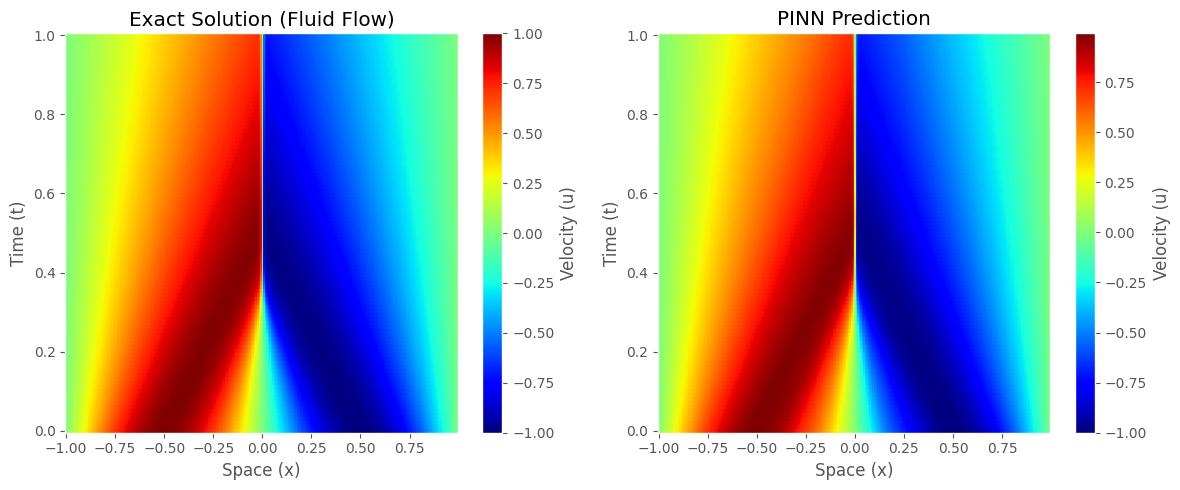

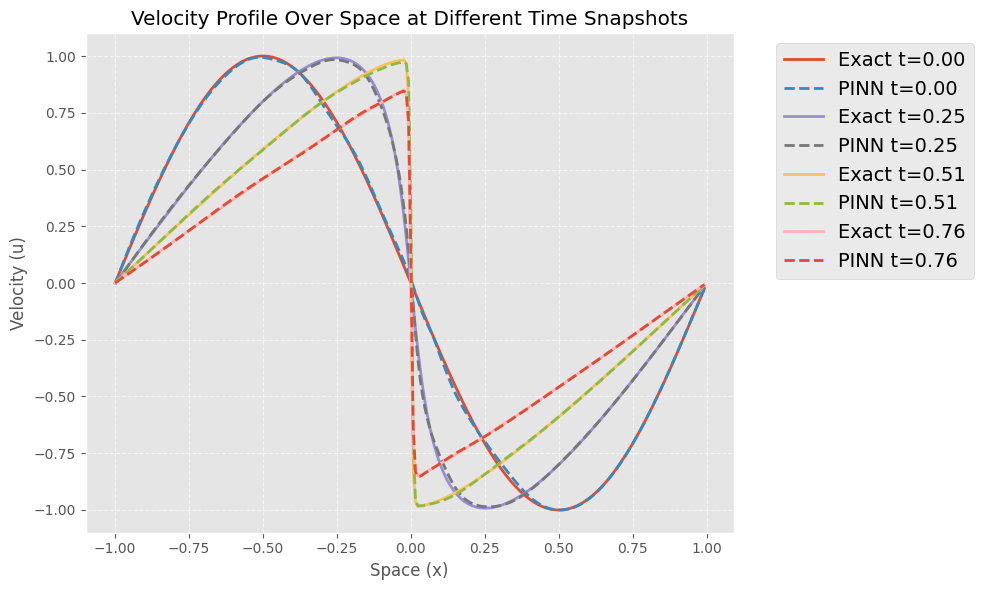

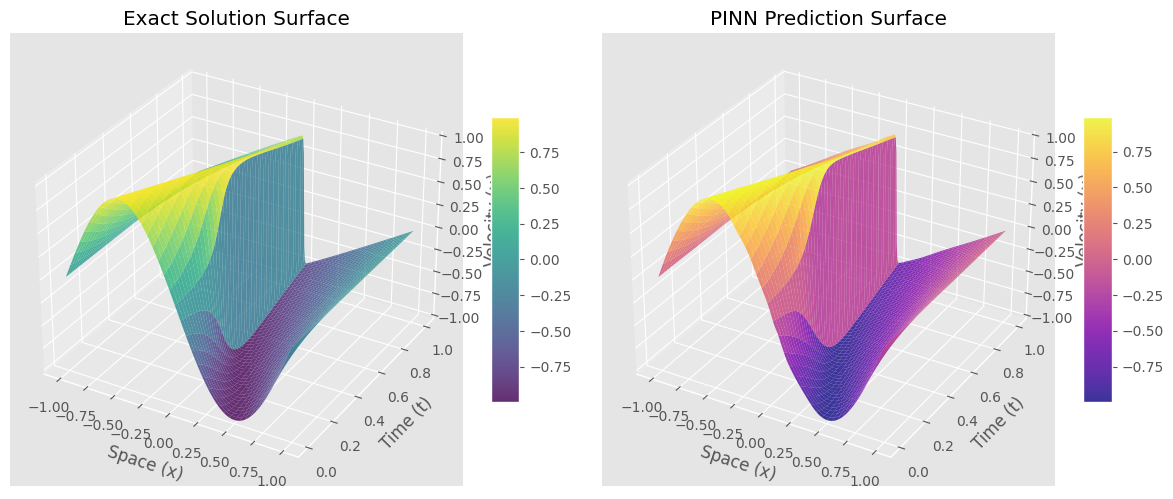

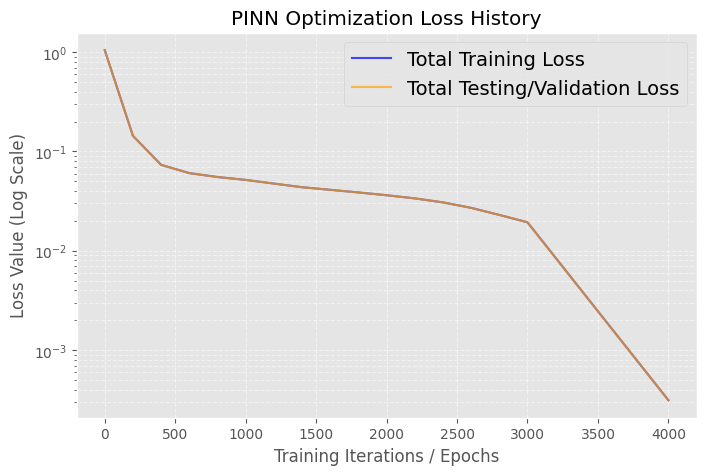

In [41]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# Set a standard built-in style safely without calling .available
plt.style.use('ggplot')

# Reshape prediction output into a 2D spatial-temporal matrix grid
U_pred_grid = u_pred.reshape(len(t_grid), len(x_grid))
U_true_grid = usol

# ==============================================================================
# 1. 2D SPATIO-TEMPORAL HEATMAP (Contour Plot)
# ==============================================================================
plt.figure(figsize=(12, 5))

# Plot True Solution Heatmap
plt.subplot(1, 2, 1)
plt.pcolormesh(X_mesh, T_mesh, U_true_grid, cmap='jet', shading='auto')
plt.colorbar(label='Velocity (u)')
plt.title('Exact Solution (Fluid Flow)')
plt.xlabel('Space (x)')
plt.ylabel('Time (t)')

# Plot Predicted Solution Heatmap
plt.subplot(1, 2, 2)
plt.pcolormesh(X_mesh_test, T_mesh_test, U_pred_grid, cmap='jet', shading='auto')
plt.colorbar(label='Velocity (u)')
plt.title('PINN Prediction')
plt.xlabel('Space (x)')
plt.ylabel('Time (t)')

plt.tight_layout()
plt.show()


# ==============================================================================
# 2. 1D SNAPSHOTS / LINE PROFILES
# ==============================================================================
plt.figure(figsize=(10, 6))
# Select specific time snapshots indices to compare (e.g., t = 0.0, 0.25, 0.50, 0.75)
snapshot_indices = [0, 25, 50, 75]

for idx in snapshot_indices:
    actual_time = t_grid[idx][0]
    # Plot true data as solid lines, PINN prediction as dashed lines
    plt.plot(x_grid, U_true_grid[idx, :], label=f'Exact t={actual_time:.2f}', linewidth=2)
    plt.plot(x_grid, U_pred_grid[idx, :], '--', label=f'PINN t={actual_time:.2f}', linewidth=2)

plt.title("Velocity Profile Over Space at Different Time Snapshots")
plt.xlabel("Space (x)")
plt.ylabel("Velocity (u)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


# ==============================================================================
# 3. 3D SURFACE PLOT
# ==============================================================================
fig = plt.figure(figsize=(12, 6))

# True Solution 3D Surface
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
surf1 = ax1.plot_surface(X_mesh, T_mesh, U_true_grid, cmap='viridis', edgecolor='none', alpha=0.8)
ax1.set_title('Exact Solution Surface')
ax1.set_xlabel('Space (x)')
ax1.set_ylabel('Time (t)')
ax1.set_zlabel('Velocity (u)')
fig.colorbar(surf1, ax=ax1, shrink=0.5, aspect=10)

# Predicted Solution 3D Surface
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
surf2 = ax2.plot_surface(X_mesh, T_mesh, U_pred_grid, cmap='plasma', edgecolor='none', alpha=0.8)
ax2.set_title('PINN Prediction Surface')
ax2.set_xlabel('Space (x)')
ax2.set_ylabel('Time (t)')
ax2.set_zlabel('Velocity (u)')
fig.colorbar(surf2, ax=ax2, shrink=0.5, aspect=10)

plt.tight_layout()
plt.show()


# ==============================================================================
# 4. TRAINING LOSS HISTORY PLOT
# ==============================================================================
epochs = losshistory.steps
loss_train = np.sum(losshistory.loss_train, axis=1) 
loss_test = np.sum(losshistory.loss_test, axis=1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, loss_train, label='Total Training Loss', color='blue', alpha=0.7)
plt.plot(epochs, loss_test, label='Total Testing/Validation Loss', color='orange', alpha=0.7)
plt.yscale('log') 
plt.title('PINN Optimization Loss History')
plt.xlabel('Training Iterations / Epochs')
plt.ylabel('Loss Value (Log Scale)')
plt.legend()
plt.grid(True, which="both", linestyle='--', alpha=0.5)
plt.show()


In [42]:
# ==============================================================================
# OPTION A: HIGH-DENSITY FINE RESOLUTION GRID (500x500 points)
# ==============================================================================
print("\n--- Generating New High-Density Prediction Points ---")
x_dense = np.linspace(-1, 1, 500)
t_dense = np.linspace(0, 1, 500)

X_dense_mesh, T_dense_mesh = np.meshgrid(x_dense, t_dense)
dense_prediction_points = np.hstack((X_dense_mesh.flatten()[:, None], T_dense_mesh.flatten()[:, None]))

# Predict using the trained model
u_dense_pred = model.predict(dense_prediction_points)
print(f"Predicted on a fine grid! Output matrix shape: {u_dense_pred.shape}")


# ==============================================================================
# OPTION B: UNSTRUCTURED RANDOM DATA POINTS (10,000 points)
# ==============================================================================
print("\n--- Generating Unstructured Random Prediction Points ---")
# Generate random space (-1 to 1) and random time (0 to 1) coordinates
random_x = np.random.uniform(-1, 1, size=(10000, 1))
random_t = np.random.uniform(0, 1, size=(10000, 1))
random_prediction_points = np.hstack((random_x, random_t))

# Predict on random points
u_random_pred = model.predict(random_prediction_points)
print(f"Sample Random Points Coordinates:\n{random_prediction_points[:3]}")
print(f"Corresponding PINN Predictions:\n{u_random_pred[:3]}")


# ==============================================================================
# OPTION C: TARGETED SINGLE-POINT TIMELINE (Tracking x = 0.0 over time)
# ==============================================================================
print("\n--- Tracking One Spatial Coordinate over a Dense Timeline ---")
t_timeline = np.linspace(0, 1, 200)[:, None]
x_fixed = np.zeros_like(t_timeline) # Fixed at spatial point x = 0.0

single_point_points = np.hstack((x_fixed, t_timeline))

# Predict velocity timeline for that single point
u_timeline_pred = model.predict(single_point_points)

# Quick validation check: at x=0, due to symmetry, u should remain near 0
print(f"Average velocity at center point (x=0) over time: {np.mean(u_timeline_pred):.6f}")



--- Generating New High-Density Prediction Points ---
Predicted on a fine grid! Output matrix shape: (250000, 1)

--- Generating Unstructured Random Prediction Points ---
Sample Random Points Coordinates:
[[ 0.74292118  0.17169399]
 [ 0.60734415  0.10253454]
 [-0.62685988  0.61259281]]
Corresponding PINN Predictions:
[[-0.5072184 ]
 [-0.82063602]
 [ 0.40033707]]

--- Tracking One Spatial Coordinate over a Dense Timeline ---
Average velocity at center point (x=0) over time: 0.108037


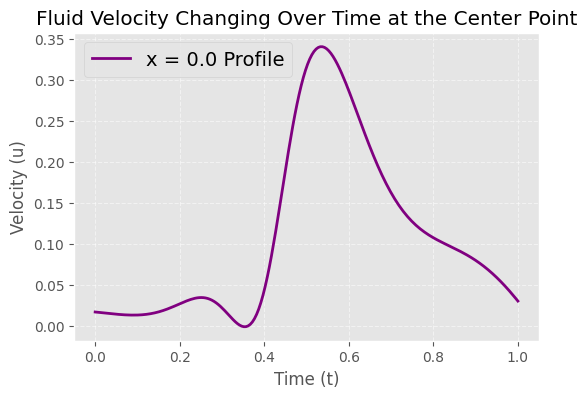

In [43]:
plt.figure(figsize=(6, 4))
plt.plot(t_timeline, u_timeline_pred, color='purple', label='x = 0.0 Profile', linewidth=2)
plt.title("Fluid Velocity Changing Over Time at the Center Point")
plt.xlabel("Time (t)")
plt.ylabel("Velocity (u)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


--- Generating Future Extrapolation Points (t = 1.0 to 1.5) ---
Extrapolation points successfully generated. Matrix shape: (10000, 1)
--- Exporting Extrapolation Dataset to 'Burgers_future_predictions.csv' ---
Export complete! Saved 10000 structural row rows to file.

First few rows of the generated CSV file:
   Spatial_Coordinate_X  Temporal_Coordinate_T  Predicted_Velocity_U
0             -1.000000                    1.0              0.006190
1             -0.989950                    1.0              0.013184
2             -0.979899                    1.0              0.020201
3             -0.969849                    1.0              0.027242
4             -0.959799                    1.0              0.034308


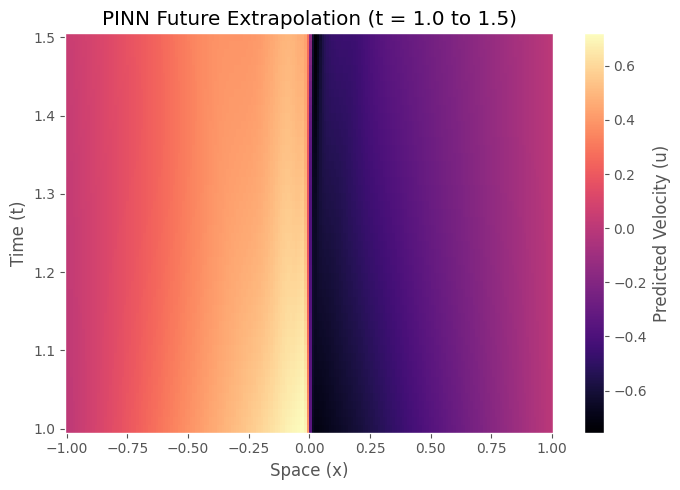

In [44]:
import pandas as pd

# ==============================================================================
# 1. EXTRAPOLATION: GENERATING POINTS OUTSIDE TRAINING TIME (t = 1.0 to 1.5)
# ==============================================================================
print("\n--- Generating Future Extrapolation Points (t = 1.0 to 1.5) ---")

# Keep the original spatial range, but shift the temporal range forward
x_extrapolate = np.linspace(-1, 1, 200)
t_extrapolate = np.linspace(1.0, 1.5, 50)  # Future timestamps

# Construct the spatial-temporal meshgrid coordinate arrays
X_ext, T_ext = np.meshgrid(x_extrapolate, t_extrapolate)
extrapolation_points = np.hstack((X_ext.flatten()[:, None], T_ext.flatten()[:, None]))

# Run inference using the trained PINN model
u_extrapolation_pred = model.predict(extrapolation_points)
print(f"Extrapolation points successfully generated. Matrix shape: {u_extrapolation_pred.shape}")


# ==============================================================================
# 2. DATA EXPORT: WRITING RESULTS TO A CSV FILE
# ==============================================================================
csv_filename = "Burgers_future_predictions.csv"
print(f"--- Exporting Extrapolation Dataset to '{csv_filename}' ---")

# Structure the spatial coordinates, temporal frames, and predictions into a pandas DataFrame
export_data = pd.DataFrame({
    'Spatial_Coordinate_X': extrapolation_points[:, 0],
    'Temporal_Coordinate_T': extrapolation_points[:, 1],
    'Predicted_Velocity_U': u_extrapolation_pred.flatten()
})

# Save to disk as a CSV file (dropping row index numbering)
export_data.to_csv(csv_filename, index=False)
print(f"Export complete! Saved {len(export_data)} structural row rows to file.")

# Display a quick structural snippet of the output file
print("\nFirst few rows of the generated CSV file:")
print(export_data.head())


# ==============================================================================
# 3. VISUALIZING THE FUTURE EXTRAPOLATION
# ==============================================================================
plt.figure(figsize=(7, 5))
U_ext_grid = u_extrapolation_pred.reshape(len(t_extrapolate), len(x_extrapolate))

# Generate a spatial-temporal plot to watch the wave decay into the future
plt.pcolormesh(X_ext, T_ext, U_ext_grid, cmap='magma', shading='auto')
plt.colorbar(label='Predicted Velocity (u)')
plt.title('PINN Future Extrapolation (t = 1.0 to 1.5)')
plt.xlabel('Space (x)')
plt.ylabel('Time (t)')
plt.tight_layout()
plt.show()


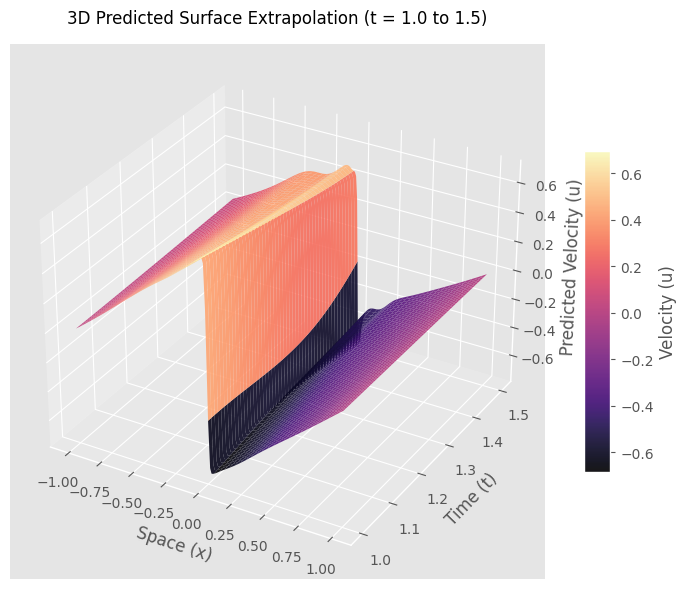

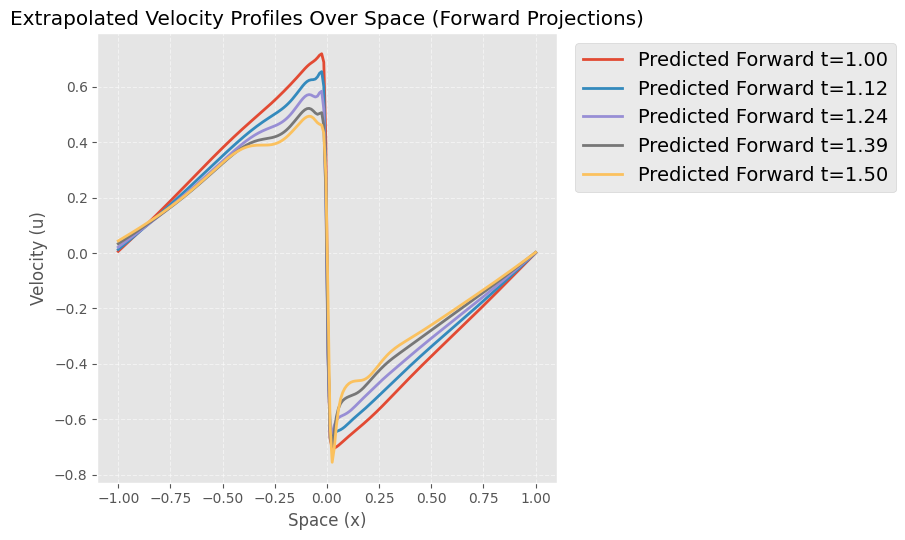

In [45]:
# ==============================================================================
# 1. 3D SURFACE PLOT FOR FUTURE EXTRAPOLATION DATA
# ==============================================================================
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(1, 1, 1, projection='3d')

# U_ext_grid and meshgrids (X_ext, T_ext) are loaded from your extrapolation step
surf = ax.plot_surface(X_ext, T_ext, U_ext_grid, cmap='magma', edgecolor='none', alpha=0.9)

ax.set_title('3D Predicted Surface Extrapolation (t = 1.0 to 1.5)', fontsize=12, pad=15)
ax.set_xlabel('Space (x)')
ax.set_ylabel('Time (t)')
ax.set_zlabel('Predicted Velocity (u)')

# Add a floating colorbar bar
fig.colorbar(surf, ax=ax, shrink=0.6, aspect=12, label='Velocity (u)')
plt.tight_layout()
plt.show()


# ==============================================================================
# 2. 1D FUTURE TIMESTEP SNAPSHOTS (Tracking Wave Decay over Time)
# ==============================================================================
plt.figure(figsize=(9, 5.5))

# Pick a few sample indices distributed across your 50 future time frames 
# (e.g., indices representing t=1.0, t=1.12, t=1.24, t=1.38, t=1.50)
future_snapshot_indices = [0, 12, 24, 38, 49]

for idx in future_snapshot_indices:
    future_time_val = t_extrapolate[idx]
    # Plotting the spatial slice across the calculated 2D grid matrix
    plt.plot(x_extrapolate, U_ext_grid[idx, :], label=f'Predicted Forward t={future_time_val:.2f}', linewidth=2)

plt.title("Extrapolated Velocity Profiles Over Space (Forward Projections)")
plt.xlabel("Space (x)")
plt.ylabel("Velocity (u)")
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
